In [1]:
# Automatically reload the package if you edit the .py files
%load_ext autoreload
%autoreload 2

import warnings; warnings.filterwarnings("ignore") # remove scanpy warnings for the tutorial.
# Import the new package name
import decipher as dc

In [2]:
dc.pl.activate_journal_quality()

# Load data

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scanpy as sc 

In [4]:
import matplotlib
print(matplotlib.__version__)
import IPython
print(IPython.__version__)

3.10.8
9.12.0


In [5]:
import os
print(os.getcwd())

/Users/jihyunpark/Documents/Columbia/2026 Spring/Decipher Project/decipher-bc-condition-v-to-z/examples


In [6]:
color_palette = None
path = '/Users/jihyunpark/Documents/Columbia/2026 Spring/Decipher Project/xenium_exploration/20260207_adata_preprocessed_full.h5ad'
adata = sc.read_h5ad(path)
adata.uns["color_palette"] = None

In [7]:
print(adata.obs.head())

   centroid_x  centroid_y  centroid_z   fov  cluster     volume  population  \
0   7722.9272   18737.640   17.120724  AD13        6   617.8711         605   
1   2909.9478   18718.960   22.409761   AD5        5  1088.7891          54   
2   5807.2960    2917.828   23.243540   I10        6   998.6133         298   
3   4885.3643   10135.514   18.992750    S8        5   985.2539         106   
5   4729.0880   10498.147   21.474840    S8        9  2949.0820         624   

   cell_num  Unnamed: 0  sample_num  ... treatment_status  OS_cat  \
0  cell_0_1           0        78.0  ...        untreated     low   
1  cell_1_1           1        75.0  ...          treated     low   
2  cell_3_1           3         7.0  ...        untreated  medium   
3  cell_5_1           5        34.0  ...        untreated    high   
5  cell_7_1           7        34.0  ...        untreated    high   

     sample_name   ex_group  cell_type_L2 cell_type_L1 cell_type_L0  \
0    S16-2647 B2  inflammed         tum

In [8]:
print(adata.obs.columns)

Index(['centroid_x', 'centroid_y', 'centroid_z', 'fov', 'cluster', 'volume',
       'population', 'cell_num', 'Unnamed: 0', 'sample_num', 'sample_id',
       'sample_type', 'TMA', 'batch', 'log10_total_counts', 'leiden',
       'density_status', 'atypical', 'deviation_score', 'log_lib_size',
       'cell_type', 'TMA_ID', 'OS_days',
       'survival sample date to death (days)',
       'treatment_(0= no treatment before biopsy; 1=treatment before biopsy)',
       'biopsy_site',
       'biopsy_site_classification (0 = unkwn; 1 = head and neck; 2 = thoracic; 3 = non-head and neck or thoracic; 4 = LN)',
       'sample site: primary vs met',
       'primary site classification (0 = unkwn; 1 = head and neck; 2 = thoracic; 3 = non-head and neck or thoracic)',
       'age_(yrs)', 'sex', 'PDL1 (TPS%)', 'PDL1: 0 = <1%; 1 = >=1%',
       'NUT-fusion: 0 = unkwn; 1 = BRD4-NUT; 2 = BRD3-NUT; 3 = NSD3-NUT; 4 = ZNF532-NUT; 5 = ZNF592-NUT',
       'note:', 'Registry participant? (YES/n)', 'NC registry 

In [9]:
import pandas as pd
pd.crosstab(adata.obs['TMA'], adata.obs['batch'])

batch,0,1
TMA,,
479,0,403192
480,292068,0


In [10]:
adata.obs = adata.obs.rename(columns={'batch': 'TMA_batch'})

In [11]:
print(adata.obs['TMA_batch'].value_counts())

TMA_batch
1    403192
0    292068
Name: count, dtype: int64


In [23]:
print(adata.obs['sample_id'].value_counts())

sample_id
S20-8605 S12          46200
S21-21003 D5          34755
BS21-36819            31410
1621120 B             31264
HS21-6527 2E-17       30975
SF11-7078 A90         27272
SP19-6233 B3          26053
10AH 4757 D           25103
RA18-12 68_4 AOARN    22808
BS12-37078            21789
MS16-1923 C20         20481
S16-2647 B2           20355
S12-34323 B5          18486
11015 IV B06          18156
BS18-37343 G12        17656
20:LP043462 D         17082
BS20-44437            16116
S16-25171 A1          15224
BA12-166 A2           14064
S17-41443 A1          13552
S19-27363 2B          12773
10-6031               12121
24556 2               11879
S12-9748 B2           11773
2151/06               11675
AM autopsy y1         11473
S14-6644 2B           11446
LHS17-11125 A4        11151
S18-2293 B4           11006
S15-105098 B1         10785
HS16-10538 A3         10440
BS10-K27219           10030
S21-6166 B5            9568
BS20-28340 D11         9400
S00-24573              8480
SUH15-1147

In [12]:
# 2. Sample 25,000 cells from every group in the 'batch' column
sampled_indices = (
    adata.obs.groupby('TMA_batch')
    .sample(n=25000, random_state=42)
    .index
)

# 3. Slice the original AnnData object
adata_balanced = adata[sampled_indices].copy()

# Verification
print(adata_balanced.obs['TMA_batch'].value_counts())

TMA_batch
0    25000
1    25000
Name: count, dtype: int64


In [47]:
# Ensure we treat them as strings if they are categories
adata_batch0 = adata[adata.obs['TMA_batch'].astype(str) == '0']
adata_batch1 = adata[adata.obs['TMA_batch'].astype(str) == '1']

# Safety Check: Print sizes to confirm they aren't empty
print(f"Batch 0 size: {adata_batch0.n_obs}")
print(f"Batch 1 size: {adata_batch1.n_obs}")

Batch 0 size: 292068
Batch 1 size: 403192


In [48]:
batch0_subset = sc.pp.subsample(adata_batch0, n_obs=50000, random_state=42, copy=True)
batch1_subset = sc.pp.subsample(adata_batch1, n_obs=50000, random_state=42, copy=True)

In [15]:
print(batch0_subset.layers['counts'][:5, :5])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 10 stored elements and shape (5, 5)>
  Coords	Values
  (0, 0)	3.2277427
  (0, 3)	1.1900218
  (1, 3)	23.600454
  (2, 1)	0.0100001
  (2, 0)	1.6100364
  (2, 3)	54.714066
  (3, 3)	2.9387991
  (4, 1)	0.0400004
  (4, 4)	0.3700037
  (4, 3)	1.7000271


If the max is < 20: You are likely looking at Log-normalized data. Do not round. You need to find the actual raw counts layer.

If the max is > 100: You are likely looking at Corrected counts (like CellBender). Rounding is safe and necessary.

In [16]:
print(batch0_subset.layers['counts'].max())

1256.8799


The 'counts' layer contained fractional values, likely due to ambient RNA correction or scaling. I rounded these to the nearest integer to satisfy the integer-count requirement of the Negative Binomial likelihood in our Decipher model.

In [49]:
import scipy.sparse as sp

def round_counts(adata):
    counts = adata.layers['counts'].copy()
    if sp.issparse(counts):
        counts.data = counts.data.round().astype(int)
    else:
        counts = counts.round().astype(int)
    adata.X = counts
    return adata

batch0_subset_dc = round_counts(batch0_subset)
batch1_subset_dc = round_counts(batch1_subset)
adata_balanced_dc = round_counts(adata_balanced)


# Train Decipher

In [55]:
plt.rcParams['axes.titlesize'] = 15

In [53]:
adata_balanced_dc1 = adata_balanced_dc.copy()

# Ensure the 'decipher' key exists in the metadata
if "decipher" not in adata_balanced_dc1.uns:
    adata_balanced_dc1.uns["decipher"] = {}
    
# Manually stamp the batch_key used during training (e.g., 'TMA_batch')
# This is the step that fixes the "No Batch Correction" title issue
adata_balanced_dc1.uns["decipher"]["config"] = {"batch_key": "TMA_batch"}

Epoch 17 (batch 703/703) | | train elbo: 238.91 (last epoch: 238.95) | val ll: 251.91:   2%|▏         | 17/1000 [08:29<8:10:38, 29.95s/it]2026-04-29 14:53:59,418 | INFO : Early stopping has been triggered.
2026-04-29 14:54:00,074 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-04-29 14:54:00,076 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-04-29 14:54:00,078 | INFO : Saving decipher model with run_id 2026-04-29-14-54-00-quantum-green-quantum.


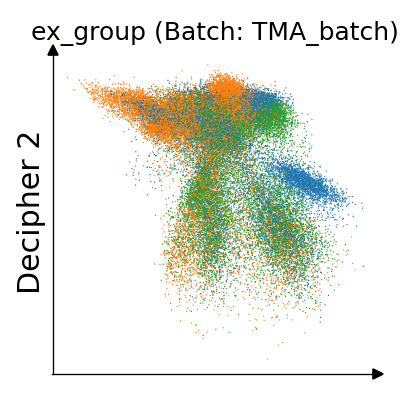

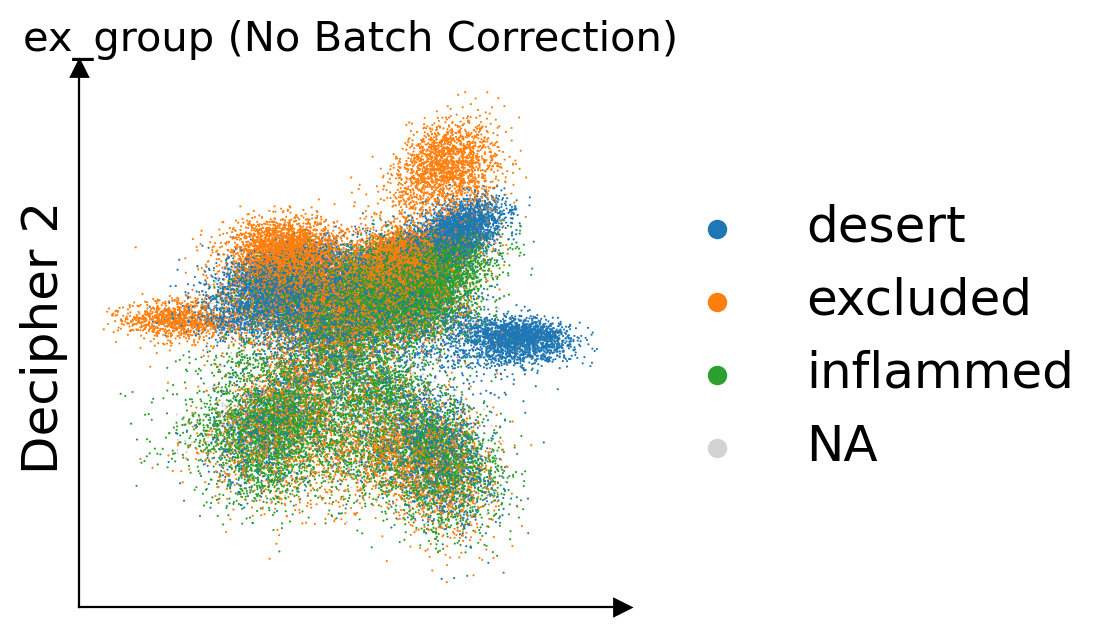

In [62]:
# Lower learning rate
from decipher.tools._decipher import DecipherConfig
decipher_config = DecipherConfig(learning_rate=1e-3)

# Train Decipher
d1, val1 = dc.tl.decipher_train(
    adata_balanced_dc1, decipher_config, 
    plot_kwargs={"color": "ex_group"}, 
    batch_key="TMA_batch",
    plot_every_k_epochs=5,
)

In [57]:
adata_balanced_dc2 = adata_balanced_dc.copy()

# Ensure the 'decipher' key exists in the metadata
if "decipher" not in adata_balanced_dc2.uns:
    adata_balanced_dc2.uns["decipher"] = {}
    
# Manually stamp the batch_key used during training (e.g., 'TMA_batch')
# This is the step that fixes the "No Batch Correction" title issue
adata_balanced_dc2.uns["decipher"]["config"] = {"batch_key": "sample_id"}

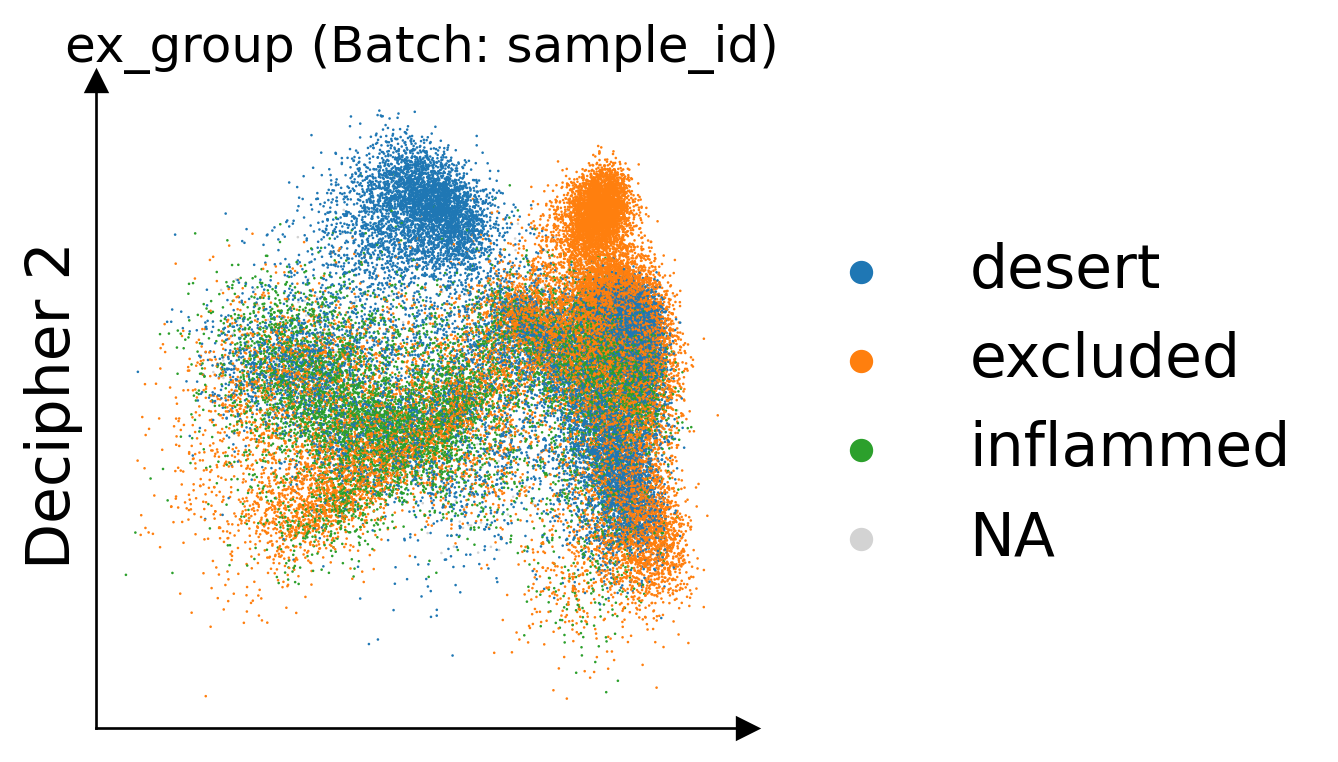

Epoch 3 (batch 521/703) | | train elbo: 241.23 (last epoch: 243.41) | val ll: 250.02:   0%|          | 3/1000 [05:11<28:42:37, 103.67s/it]


KeyboardInterrupt: 

In [ ]:
batch_decipher_config = DecipherConfig(learning_rate=1e-3)
# Train Decipher
d2, val2 = dc.tl.decipher_train(
    batch0_subset_dc, decipher_config, 
    plot_kwargs={"color": "ex_group"}, 
    batch_key="sample_id",
    plot_every_k_epochs=5,
)

In [60]:
adata_balanced_dc3 = adata_balanced_dc.copy()

# Ensure the 'decipher' key exists in the metadata
if "decipher" not in adata_balanced_dc3.uns:
    adata_balanced_dc3.uns["decipher"] = {}
    
# Manually stamp the batch_key used during training (e.g., 'TMA_batch')
# This is the step that fixes the "No Batch Correction" title issue
adata_balanced_dc3.uns["decipher"]["config"] = {"batch_key": "TMA_batch"}

Epoch 17 (batch 703/703) | | train elbo: 238.91 (last epoch: 238.95) | val ll: 251.91:   2%|▏         | 17/1000 [21:45<20:58:13, 76.80s/it]2026-04-29 14:17:55,003 | INFO : Early stopping has been triggered.
2026-04-29 14:17:56,028 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-04-29 14:17:56,029 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-04-29 14:17:56,032 | INFO : Saving decipher model with run_id 2026-04-29-14-17-56-cyclic-maroon-burger.


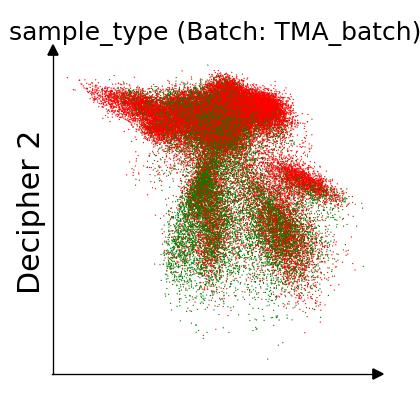

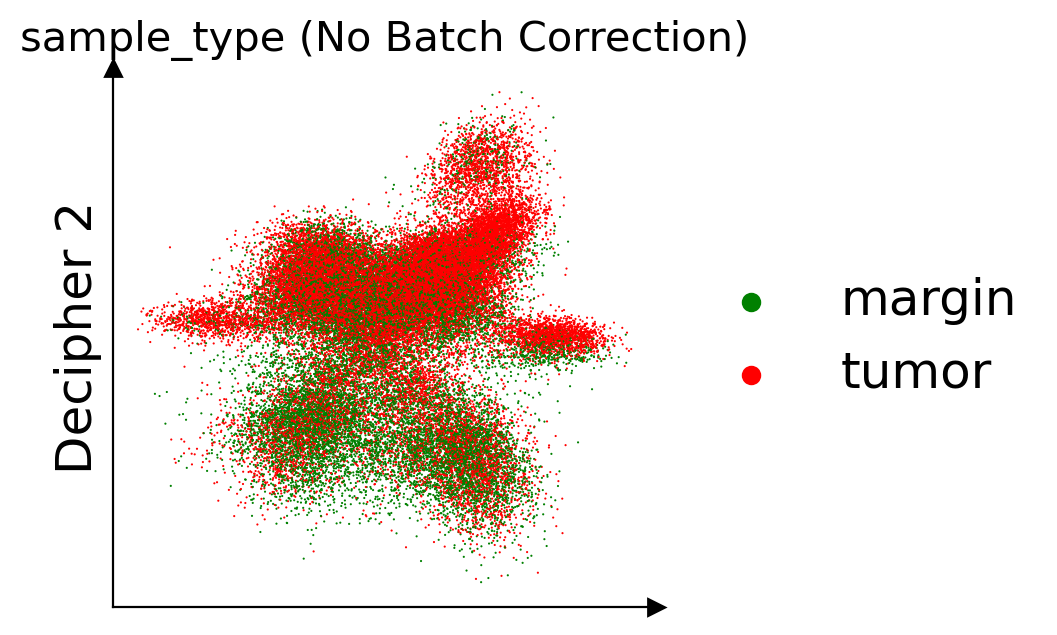

In [61]:
# Train Decipher
d3, val3 = dc.tl.decipher_train(
    adata_balanced_dc3, decipher_config, 
    plot_kwargs={"color": "sample_type"}, 
    batch_key="TMA_batch",
    plot_every_k_epochs=5,
)